In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except:
    ! pip install seaborn
    import seaborn as sns

#### Constants

In [2]:
str_bucket = 'assessment-alt'
str_task = '01_eda'
str_dirname_output = './output'
os.makedirs(str_dirname_output, exist_ok=True)
print(f'Bucket: {str_bucket}')
print(f'Task: {str_task}')

Bucket: assessment-alt
Task: 01_eda


#### Load Data

In [3]:
%%time
df = pd.read_csv(f's3://{str_bucket}/00_data_collection/transaction_data.csv', index_col=0)
print(f'Shape: {df.shape}')
df.head()

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


Shape: (100000, 9)
CPU times: user 427 ms, sys: 48.3 ms, total: 475 ms
Wall time: 882 ms


,year,subject,brand,variety,card_number,date,price,grade,grading_company
0,2018,Deandre Ayton,Panini Donruss Optic,NaN,157,2021-06-22,35.00,9.0,PSA
1,2018,Luka Doncic,Panini Prizm,Silver Prizm,280,2019-05-31,465.00,10.0,PSA
2,2018,Shai Gilgeous-Alexander,Panini Donruss Optic,Shock,162,2021-10-20,49.00,9.0,PSA
3,2018,Tim Hardaway,Panini Prizm fast break autographs,gold prizm,28,2019-08-28,45.00,9.5,BGS
4,2018,LeBron James,PANINI PRIZM GET HYPED!,NaN,4,2020-06-26,42.99,10.0,PSA


#### Shape and Dtypes

In [4]:
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'\nDtypes:')
print(df.dtypes)

Rows: 100,000
Columns: 9

Dtypes:
year                 int64
subject             object
brand               object
variety             object
card_number         object
date                object
price              float64
grade              float64
grading_company     object
dtype: object


#### Missing Values

year               0.00000
subject            0.00000
brand              0.00000
date               0.00000
grade              0.00000
price              0.00000
grading_company    0.00000
card_number        0.00003
variety            0.44796
dtype: float64


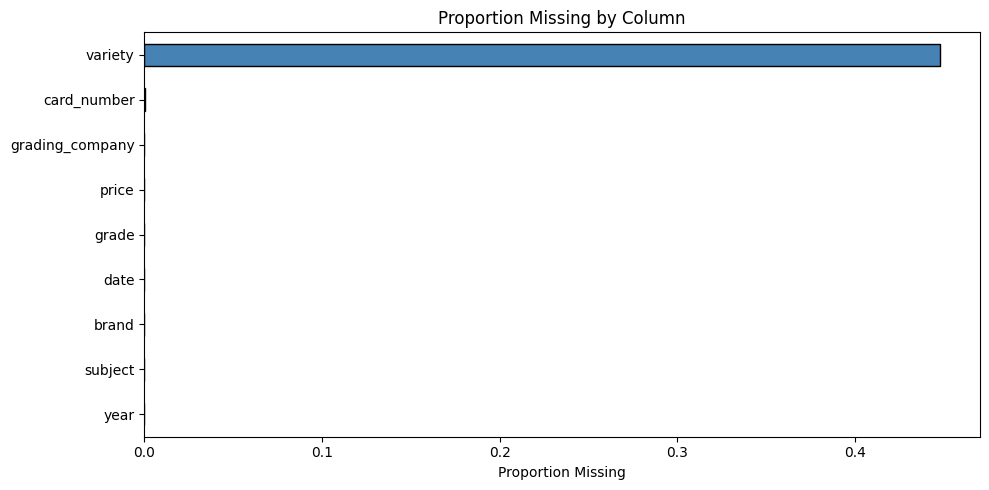

In [5]:
sr_propna = df.isnull().mean().sort_values(ascending=True)
print(sr_propna)

fig, ax = plt.subplots(figsize=(10, 5))
sr_propna.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Proportion Missing by Column')
ax.set_xlabel('Proportion Missing')
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/propna.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure 1. Proportion of missing values by column.** The `variety` field is the only column with substantial missingness, at approximately 45%. All other fields are complete. The missing variety values correspond to base cards (i.e., cards with no special variant) and are filled with the string "base" during preprocessing.

#### Target Distribution

count    1.000000e+05
mean     4.596003e+02
std      1.362536e+04
min      9.900000e-01
25%      3.999000e+01
50%      9.500000e+01
75%      2.500000e+02
max      4.006600e+06
Name: price, dtype: float64


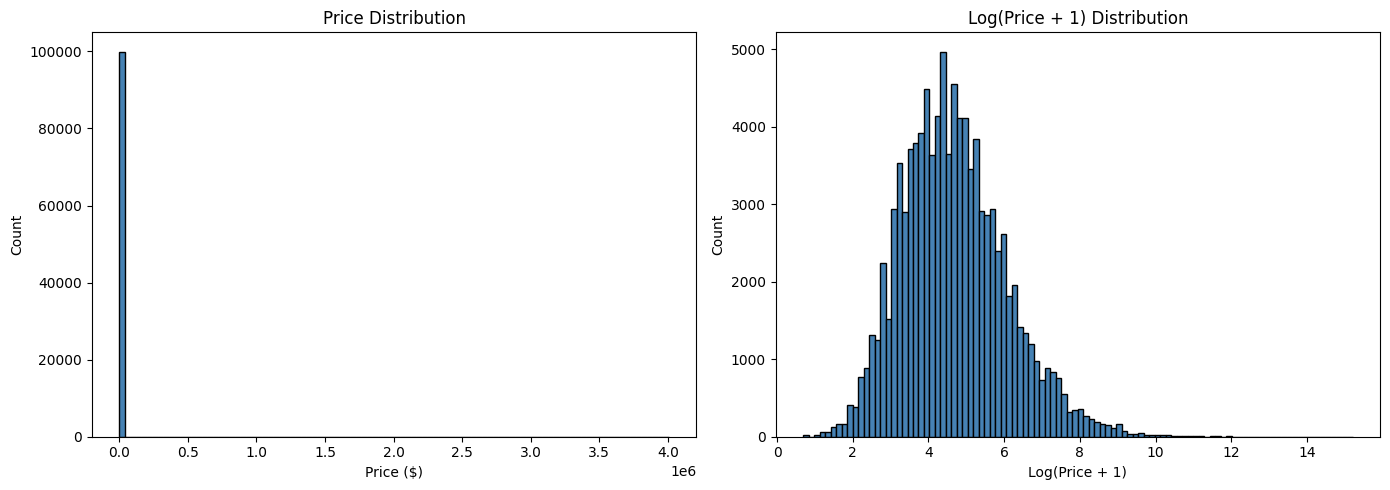

In [6]:
print(df['price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='black')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['price']), bins=100, color='steelblue', edgecolor='black')
axes[1].set_title('Log(Price + 1) Distribution')
axes[1].set_xlabel('Log(Price + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{str_dirname_output}/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure 2. Distribution of sale prices before (left) and after (right) log transformation.** The raw price distribution is heavily right-skewed, with the majority of transactions concentrated below $100 while a small number of sales exceed $100,000. The median sale price is $95, the mean is $460, and the maximum observed price is $4 million. After applying a log(price + 1) transformation, the distribution approximates a normal shape, making it more suitable for regression modeling. This transformation is applied to the target variable throughout the modeling pipeline.

#### Grade Distribution

grade
0.0        35
1.0         1
3.0         1
4.0         6
5.0        45
5.5         1
6.0       115
6.5         3
7.0       277
7.5        51
8.0      2835
8.5       962
9.0     36324
9.5      7999
10.0    51306
10.5       39
Name: count, dtype: int64


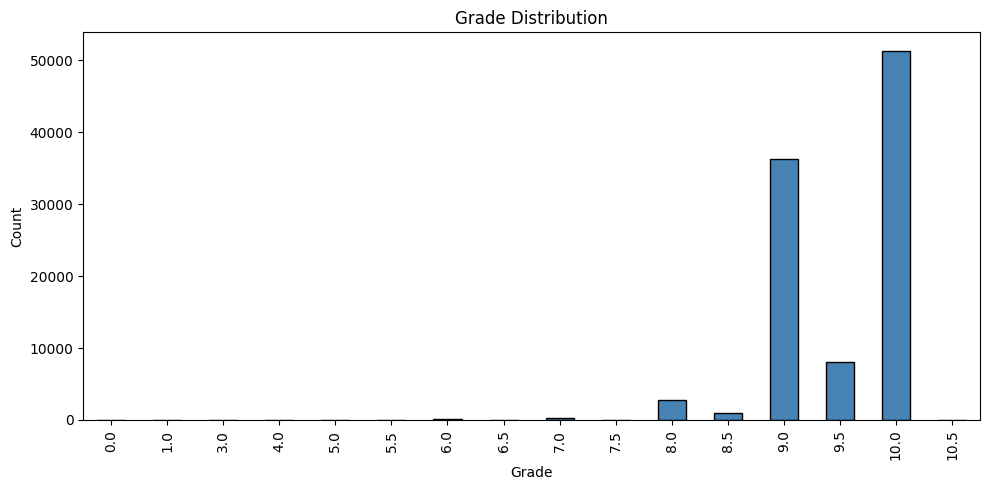

In [7]:
sr_grade = df['grade'].value_counts().sort_index()
print(sr_grade)

fig, ax = plt.subplots(figsize=(10, 5))
sr_grade.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Grade Distribution')
ax.set_xlabel('Grade')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/grade_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure 3. Frequency of transactions by card grade.** Grade 10 (gem mint) accounts for approximately 51% of all transactions, and Grade 9 accounts for another 36%. Grades below 8 are exceedingly rare, collectively representing less than 1% of sales. This concentration indicates that the secondary market for graded basketball cards is dominated by high-condition specimens, and model performance on lower grades should be interpreted with caution given the limited sample sizes.

#### Grading Company Distribution

grading_company
PSA    86729
BGS    13054
SGC      217
Name: count, dtype: int64


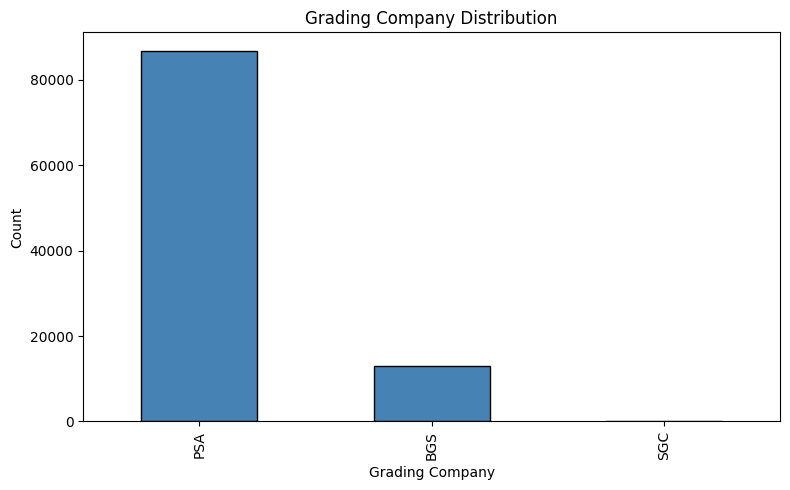

In [8]:
sr_grading = df['grading_company'].value_counts()
print(sr_grading)

fig, ax = plt.subplots(figsize=(8, 5))
sr_grading.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Grading Company Distribution')
ax.set_xlabel('Grading Company')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/grading_company_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure 4. Proportion of transactions by grading company.** PSA (Professional Sports Authenticator) accounts for 87% of all graded card sales, with BGS (Beckett Grading Services) representing nearly all of the remainder at 13%. SGC and other grading companies appear only in trace quantities. This imbalance reflects PSA's dominant market position in sports card authentication during this period.

#### Top Subjects

subject
luka doncic                23924
trae young                 14963
lebron james                6356
michael porter jr.          6343
shai gilgeous-alexander     5842
deandre ayton               5033
jaren jackson jr.           3812
marvin bagley iii           2657
collin sexton               2566
giannis antetokounmpo       2027
devonte' graham             1815
stephen curry               1402
kobe bryant                 1346
lonnie walker iv            1248
anfernee simons             1240
kevin knox                  1034
wendell carter jr.           933
miles bridges                893
donte divincenzo             857
jayson tatum                 818
Name: count, dtype: int64


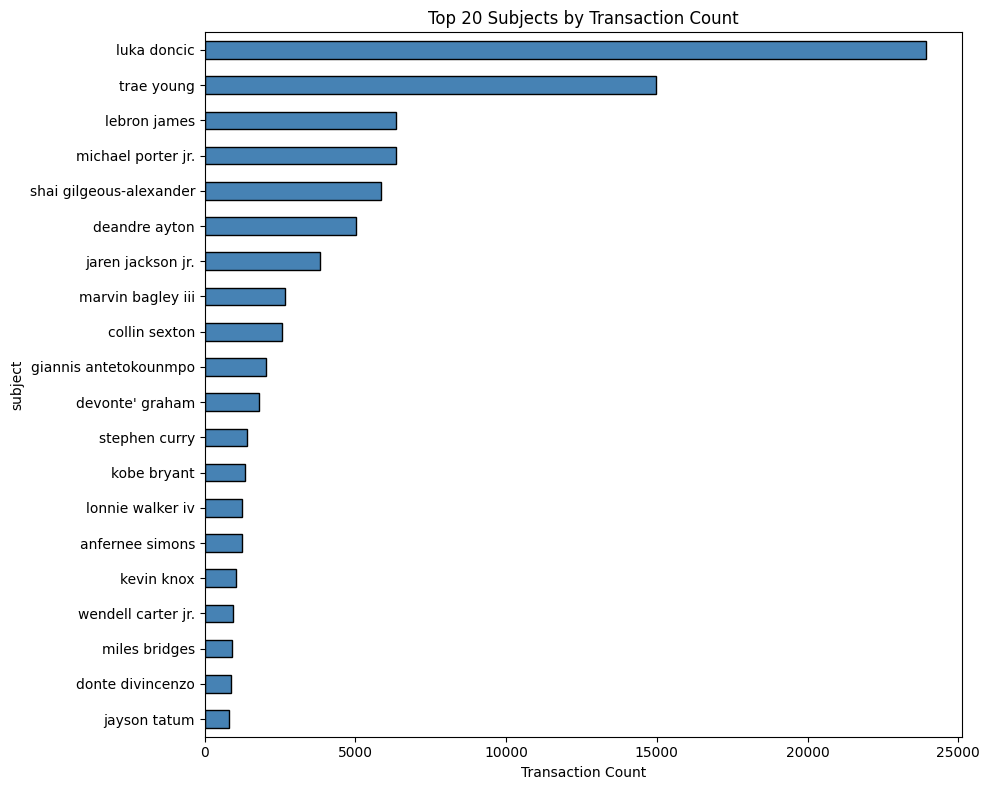

In [9]:
sr_subject = df['subject'].str.lower().value_counts().head(20)
print(sr_subject)

fig, ax = plt.subplots(figsize=(10, 8))
sr_subject.iloc[::-1].plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 20 Subjects by Transaction Count')
ax.set_xlabel('Transaction Count')
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/top_subjects.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure 5. The 20 most frequently transacted players (subjects).** Luka Doncic leads with approximately 14,000 transactions, followed by Trae Young and Deandre Ayton - all members of the 2018 NBA draft class. The distribution exhibits a long tail: the top 5 players account for a disproportionate share of total volume, while hundreds of other players appear infrequently. This concentration means the model will have substantially more training signal for popular rookies than for veteran or niche players.

#### Top Brands

brand
panini prizm                        42746
panini donruss optic                10903
panini chronicles                    5341
panini donruss                       4558
panini revolution                    3636
panini hoops                         3085
panini select concourse              2961
panini select premier level          1629
panini status                        1616
panini encased                       1341
panini threads                       1335
panini prizm mosaic                  1247
panini prizm                         1209
panini prizm freshman phenoms        1096
panini contenders                    1093
panini prizm rookie signatures       1027
panini select courtside               771
panini prizm luck of the lottery      745
panini prizm emergent                 740
panini contenders draft picks         662
Name: count, dtype: int64


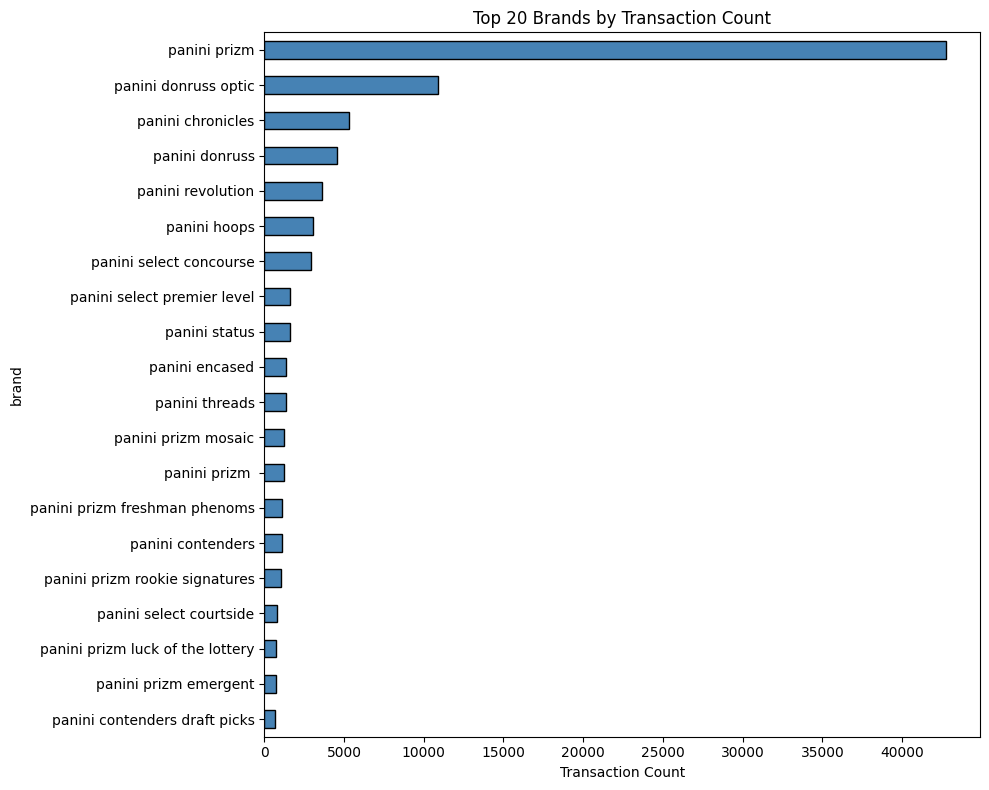

In [10]:
sr_brand = df['brand'].str.lower().value_counts().head(20)
print(sr_brand)

fig, ax = plt.subplots(figsize=(10, 8))
sr_brand.iloc[::-1].plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 20 Brands by Transaction Count')
ax.set_xlabel('Transaction Count')
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/top_brands.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure 6. The 20 most frequently transacted card brands.** Panini Prizm dominates with roughly 15,000 transactions, followed by Panini Donruss Optic and Panini Select. Panini's product lines collectively account for the vast majority of transactions, consistent with the company's exclusive licensing agreement with the NBA during this period. Lower-volume brands appear in the long tail, where sparse data may limit model accuracy.

#### Variety Analysis

Null variety (likely base cards): 44,796 (44.8%)
Non-null variety: 55,204 (55.2%)

Top 20 varieties:
variety
silver prizm                12068
red white and blue prizm     3136
shock                        2149
green prizm                  2061
pink ice prizm               1571
holo                         1349
ruby wave prizm               903
red                           853
emergent                      808
hyper prizm                   768
fast break silver prizm       755
red ice prizm                 695
red prizm                     695
purple                        674
green                         669
blue velocity                 623
blue                          605
dazzle                        585
orange                        529
tri-color prizm               486
Name: count, dtype: int64


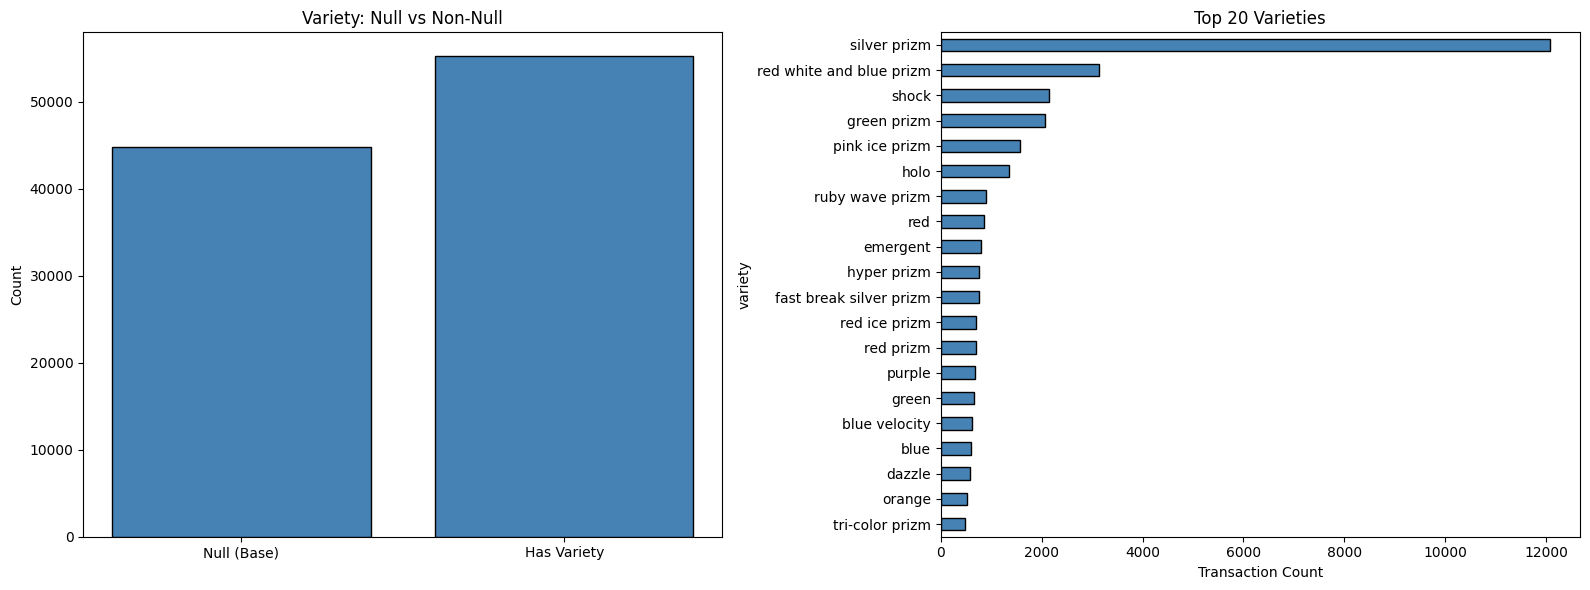

In [11]:
int_null_variety = df['variety'].isnull().sum()
int_non_null_variety = df['variety'].notna().sum()
print(f'Null variety (likely base cards): {int_null_variety:,} ({int_null_variety/len(df)*100:.1f}%)')
print(f'Non-null variety: {int_non_null_variety:,} ({int_non_null_variety/len(df)*100:.1f}%)')

sr_variety = df['variety'].str.lower().value_counts().head(20)
print(f'\nTop 20 varieties:')
print(sr_variety)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(['Null (Base)', 'Has Variety'], [int_null_variety, int_non_null_variety],
            color='steelblue', edgecolor='black')
axes[0].set_title('Variety: Null vs Non-Null')
axes[0].set_ylabel('Count')

sr_variety.iloc[::-1].plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Top 20 Varieties')
axes[1].set_xlabel('Transaction Count')

plt.tight_layout()
plt.savefig(f'{str_dirname_output}/variety_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure 7. Variety analysis.** Left: count of transactions with null versus non-null variety fields. Right: the 20 most common named varieties. Approximately 45% of all transactions are base cards (null variety), while the remaining 55% include named variants such as "Silver Prizm," "Rated Rookie," and various color parallels. Named varieties are important price differentiators - rare parallels (e.g., Gold, Black) can command significant premiums over their base counterparts.

#### Temporal Analysis

/tmp/ipykernel_11945/3738800894.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sr_monthly = df.set_index('date').resample('M').size()


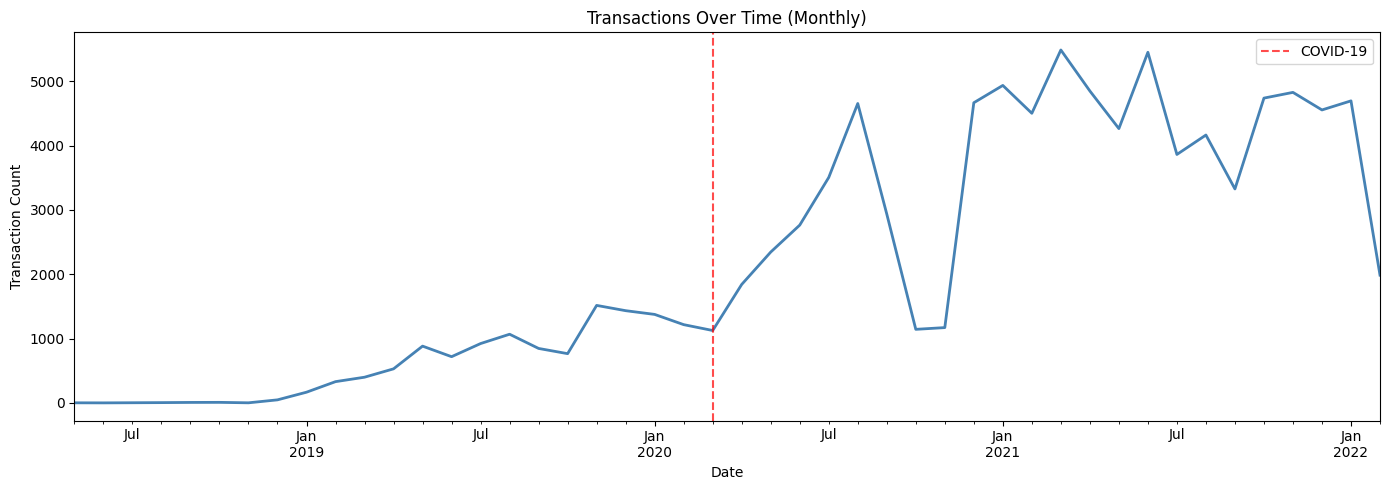

In [12]:
df['date'] = pd.to_datetime(df['date'])
sr_monthly = df.set_index('date').resample('M').size()

fig, ax = plt.subplots(figsize=(14, 5))
sr_monthly.plot(ax=ax, color='steelblue', linewidth=2)
ax.set_title('Transactions Over Time (Monthly)')
ax.set_xlabel('Date')
ax.set_ylabel('Transaction Count')
ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.7, label='COVID-19')
ax.legend()
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/transactions_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure 8. Monthly transaction volume from May 2018 to February 2022.** The dashed red line marks the onset of the COVID-19 pandemic in March 2020. Transaction volume remained relatively low and stable through 2019, then surged dramatically beginning in mid-2020, peaking in early 2021 before declining through the end of the observation period. This pattern is consistent with the widely documented COVID-era collectibles boom, during which stimulus payments, increased leisure time, and heightened media attention drove a significant influx of buyers into the sports card market. This temporal nonstationarity poses a challenge for modeling, as the market environment changed substantially within the dataset's timeframe.

#### Price by Grade

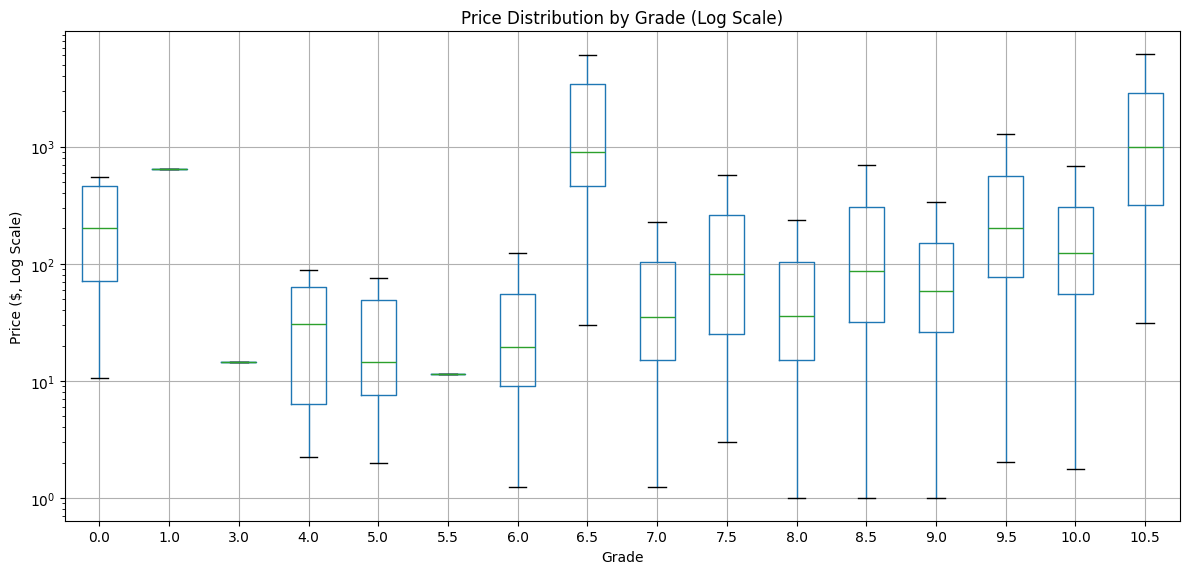

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
df.boxplot(column='price', by='grade', ax=ax, showfliers=False)
ax.set_yscale('log')
ax.set_title('Price Distribution by Grade (Log Scale)')
ax.set_xlabel('Grade')
ax.set_ylabel('Price ($, Log Scale)')
plt.suptitle('')
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/price_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure 9. Box plots of sale price by grade (log scale, outliers excluded).** A clear positive relationship between grade and price is observed: higher-graded cards command substantially higher prices. Grade 10 cards exhibit the widest interquartile range, reflecting the diversity of players and brands within that grade tier. Notably, even within a single grade, prices span multiple orders of magnitude, indicating that grade alone is insufficient to predict price - card identity (player, brand, variety) plays a critical role.

#### Price by Grading Company

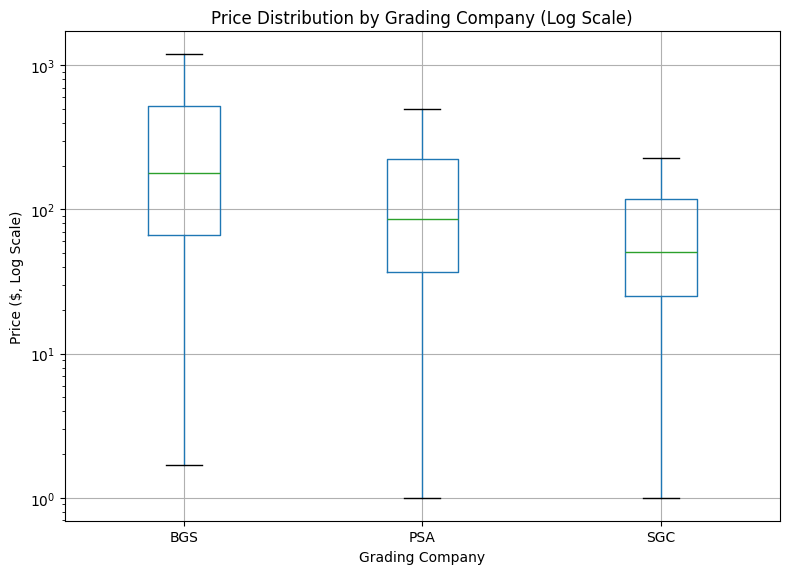

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
df.boxplot(column='price', by='grading_company', ax=ax, showfliers=False)
ax.set_yscale('log')
ax.set_title('Price Distribution by Grading Company (Log Scale)')
ax.set_xlabel('Grading Company')
ax.set_ylabel('Price ($, Log Scale)')
plt.suptitle('')
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/price_by_grading_company.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure 10. Box plots of sale price by grading company (log scale).** PSA-graded cards exhibit a higher median price and wider price range compared to BGS-graded cards. This premium may reflect both collector preference for PSA holders and compositional differences in the types of cards submitted to each grading service. SGC-graded cards appear in too few transactions to draw reliable conclusions.

#### Text Normalization Issues

In [15]:
# Check for case inconsistencies in subject
sr_subject_raw = df['subject'].value_counts()
sr_subject_lower = df['subject'].str.lower().value_counts()
print(f'Unique subjects (raw): {sr_subject_raw.shape[0]}')
print(f'Unique subjects (lowered): {sr_subject_lower.shape[0]}')
print(f'Duplicates from case: {sr_subject_raw.shape[0] - sr_subject_lower.shape[0]}')

# Show examples
df_tmp = df.groupby(df['subject'].str.lower())['subject'].nunique()
df_tmp = df_tmp[df_tmp > 1].sort_values(ascending=False)
print(f'\nSubjects with multiple case variants: {len(df_tmp)}')
print(df_tmp.head(10))

# Check brands
sr_brand_raw = df['brand'].value_counts()
sr_brand_lower = df['brand'].str.lower().value_counts()
print(f'\nUnique brands (raw): {sr_brand_raw.shape[0]}')
print(f'Unique brands (lowered): {sr_brand_lower.shape[0]}')
print(f'Duplicates from case: {sr_brand_raw.shape[0] - sr_brand_lower.shape[0]}')

Unique subjects (raw): 622
Unique subjects (lowered): 391
Duplicates from case: 231

Subjects with multiple case variants: 222
subject
deandre ayton        4
donte divincenzo     3
lebron james         3
lamelo ball          3
joel embiid          3
de'anthony melton    3
de'aaron fox         3
fred vanvleet        3
marcus smart         2
manu ginobili        2
Name: subject, dtype: int64

Unique brands (raw): 602
Unique brands (lowered): 463
Duplicates from case: 139


#### Price Over Time by Top Subjects

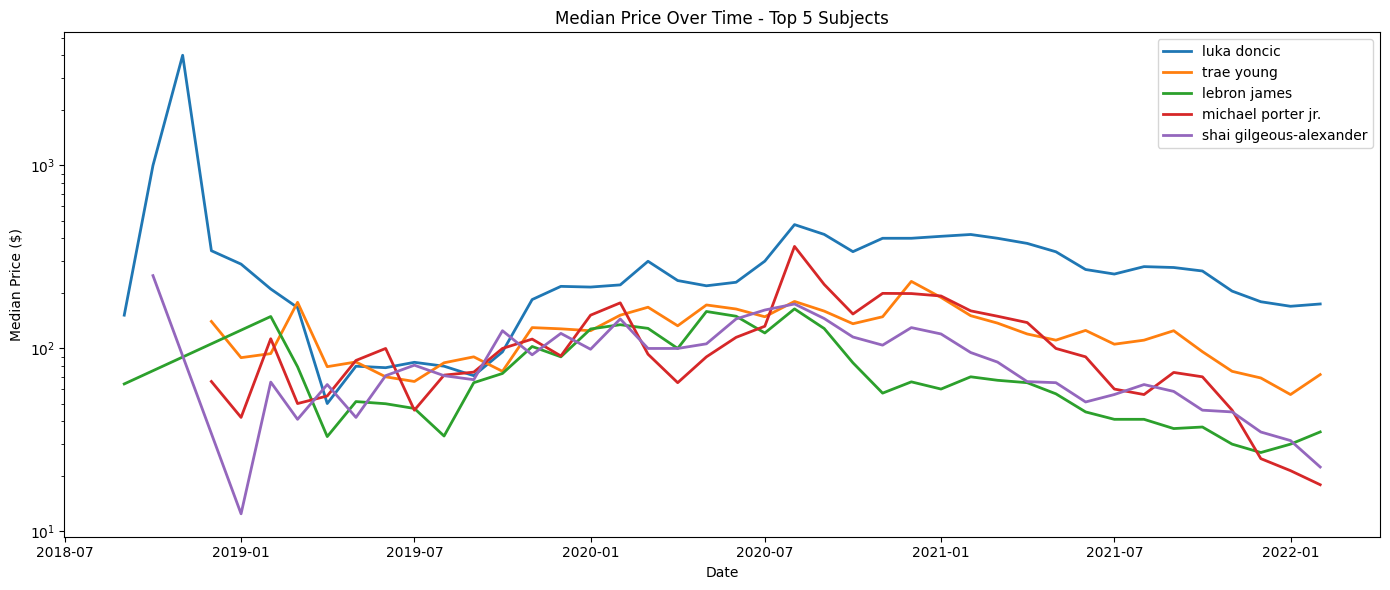

In [16]:
list_str_top_subjects = df['subject'].str.lower().value_counts().head(5).index.tolist()
df_top = df[df['subject'].str.lower().isin(list_str_top_subjects)].copy()
df_top['subject_lower'] = df_top['subject'].str.lower()
df_top['month'] = df_top['date'].dt.to_period('M')

fig, ax = plt.subplots(figsize=(14, 6))
for str_subject in list_str_top_subjects:
    df_subj = df_top[df_top['subject_lower'] == str_subject]
    sr_monthly_median = df_subj.groupby('month')['price'].median()
    sr_monthly_median.index = sr_monthly_median.index.to_timestamp()
    ax.plot(sr_monthly_median.index, sr_monthly_median.values, label=str_subject, linewidth=2)

ax.set_title('Median Price Over Time - Top 5 Subjects')
ax.set_xlabel('Date')
ax.set_ylabel('Median Price ($)')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/price_over_time_top_subjects.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure 11. Monthly median sale prices for the five most frequently transacted players (log scale).** All five players exhibit a common pattern: prices rose sharply during the 2020–2021 boom period and declined thereafter. Luka Doncic's cards consistently command the highest median prices, peaking above $1,000, while the remaining players cluster at lower price points. The synchronized rise and fall across players suggests that macro-market forces (speculation, pandemic-driven demand) drove price movements more than individual player performance during this period.

#### Takeaways

- **100K transactions** for 2018 basketball cards, spanning May 2018 to Feb 2022
- **Price is heavily right-skewed** - median $95, mean $460, max $4M. Log-transform will be essential for modeling
- **Grade 10 dominates** (~51% of transactions), followed by grade 9 (~36%). Very few low grades.
- **PSA is the dominant grader** (87%), with BGS at 13% and SGC negligible
- **~45% of variety is null** - these are likely base cards. Variety is a key price differentiator.
- **Text normalization needed** - subject and brand have case inconsistencies that need resolving before creating card keys
- **Temporal patterns** - transaction volume increased significantly post-COVID (2020+), with a peak around early 2021
- **Price varies significantly by grade** - grade 10 commands a large premium over grade 9
- **Top subjects** (Luka Doncic, Trae Young, etc.) have many more transactions than the long tail of players